# Stage 3 — Benign vs Malignant Pipeline
### 3D EfficientNet-B0 | Full Evaluation & Visualisation

**Sections:**
1. Environment & model loading
2. Dataset inspection
3. Training history curves
4. Full test-set evaluation
5. Confusion matrix & ROC curve
6. Threshold sweep
7. Per-patient probability plot
8. Patient visualiser (64³ crop + DCE kinetics)
9. Specific patient investigation
10. Random gallery
11. Summary card

In [1]:
import os, sys, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torch.amp import autocast
from torch.utils.data import DataLoader

# ── Paths ────────────────────────────────────────────────────────
PROJECT_ROOT = r"D:\Breast_Tumor_AI_Project"

# Add BOTH the project root AND the stage3 folder so imports resolve
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification", "stage3"))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src", "classification"))

from data_stage3  import Stage3Dataset, STAGE3_ROOT, CROP_SIZE
from model_stage3 import get_model_stage3

DATA_ROOT   = os.path.join(PROJECT_ROOT, "data",   "classification_stage3")
MODEL_DIR   = os.path.join(PROJECT_ROOT, "models", "classification_stage3")
LOG_JSON    = os.path.join(MODEL_DIR, "training_log.json")
CHECKPOINT  = os.path.join(MODEL_DIR, "best_model.pth")

# Fall back to best_model.pth if raw not found
if not os.path.isfile(CHECKPOINT):
    CHECKPOINT = os.path.join(MODEL_DIR, "best_model.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device    : {device}")
print(f"Crop size : {CROP_SIZE}³ patch around tumour centroid")
print(f"Data      : {DATA_ROOT}")
print(f"Checkpoint: {CHECKPOINT}")
print(f"Exists    : {os.path.isfile(CHECKPOINT)}")

Device    : cuda
Crop size : 64³ patch around tumour centroid
Data      : D:\Breast_Tumor_AI_Project\data\classification_stage3
Checkpoint: D:\Breast_Tumor_AI_Project\models\classification_stage3\best_model.pth
Exists    : True


## 1. Load Model

In [2]:
model = get_model_stage3(device)

ckpt  = torch.load(CHECKPOINT, map_location=device, weights_only=False)
# Support both full checkpoint dict and bare state_dict
state = ckpt.get("model_state", ckpt) if isinstance(ckpt, dict) else ckpt
model.load_state_dict(state)
model.eval()

epoch      = ckpt.get("epoch",       "?") if isinstance(ckpt, dict) else "?"
best_score = ckpt.get("best_score",  "?") if isinstance(ckpt, dict) else "?"
print(f"  Model loaded — epoch={epoch}  best_val_auc={best_score}")

# Load training history from JSON log
hist3 = {"val_auc": [], "train_auc": [], "val_loss": [], "train_loss": [],
          "val_f1": [], "val_sens": [], "val_spec": []}
if os.path.isfile(LOG_JSON):
    with open(LOG_JSON) as f:
        log = json.load(f)
    for row in log.get("history", []):
        for k in hist3:
            part = k.split("_", 1)
            key  = k  # exact key in row
            if key in row:
                hist3[k].append(row[key])
    print(f"  History loaded: {len(hist3['val_auc'])} epochs")
else:
    print(f"  [WARN] No training_log.json found at {LOG_JSON}")

  Stage3 Model : 3D EfficientNet-B0 (MONAI) — 4.7M params
  Output bias  : 0.0000  (neutral 50/50 prior — loss corrects via pos_weight=0.403)
  Model loaded — epoch=45  best_val_auc=0.92
  History loaded: 75 epochs


## 2. Dataset Inspection

In [3]:
summary3 = {}
for split in ("train", "val", "test"):
    summary3[split] = {"malignant": 0, "benign": 0}
    for cls in ("malignant", "benign"):
        cls_dir = os.path.join(DATA_ROOT, split, cls)
        if os.path.isdir(cls_dir):
            summary3[split][cls] = sum(
                1 for pid in os.listdir(cls_dir)
                if os.path.isfile(os.path.join(cls_dir, pid, "image.npy"))
            )

print(f"  {'Split':8s}  {'Malignant':>10s}  {'Benign':>8s}  {'Total':>7s}  {'Mal%':>6s}")
print("  " + "-"*48)
for split, counts in summary3.items():
    mal   = counts["malignant"]
    ben   = counts["benign"]
    total = mal + ben
    pct   = mal / total * 100 if total > 0 else 0
    print(f"  {split:8s}  {mal:>10d}  {ben:>8d}  {total:>7d}  {pct:>5.1f}%")

  Split      Malignant    Benign    Total    Mal%
  ------------------------------------------------
  train            221        89      310   71.3%
  val               48        22       70   68.6%
  test              54        25       79   68.4%


## 3. Training History

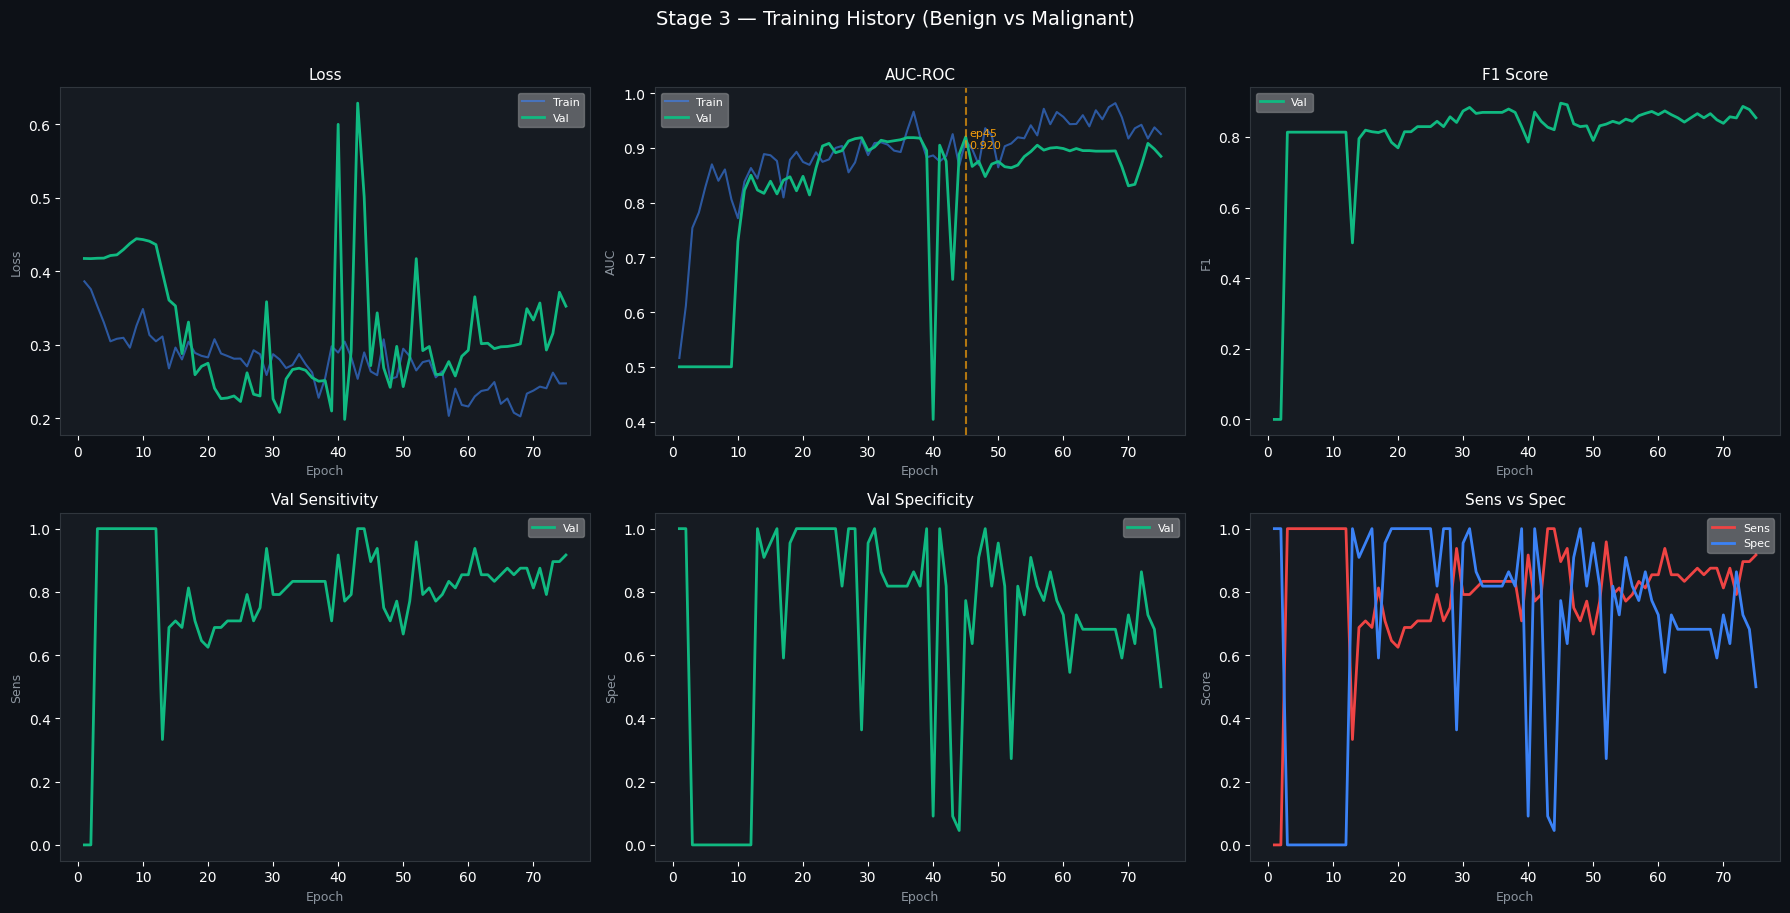

  Best val AUC: 0.9200 at epoch 45


In [11]:
if not hist3["val_auc"]:
    print("No training history found. Skipping curves.")
else:
    ep = list(range(1, len(hist3["val_auc"]) + 1))

    fig, axes = plt.subplots(2, 3, figsize=(18, 9), facecolor="#0d1117")
    fig.suptitle("Stage 3 — Training History (Benign vs Malignant)",
                 color="white", fontsize=14, y=1.01)

    def _line(ax, y_train, y_val, title, ylabel):
        ax.set_facecolor("#161b22")
        if y_train: ax.plot(ep[:len(y_train)], y_train, color="#3b82f6", lw=1.5, alpha=0.6, label="Train")
        if y_val:   ax.plot(ep[:len(y_val)],   y_val,   color="#10b981", lw=2,   label="Val")
        ax.set_title(title, color="white", fontsize=11)
        ax.set_ylabel(ylabel, color="#8b949e", fontsize=9)
        ax.set_xlabel("Epoch", color="#8b949e", fontsize=9)
        ax.tick_params(colors="white"); ax.spines[:].set_color("#30363d")
        ax.legend(fontsize=8, labelcolor="white", framealpha=0.3)

    _line(axes[0,0], hist3["train_loss"], hist3["val_loss"],  "Loss",        "Loss")
    _line(axes[0,1], hist3["train_auc"],  hist3["val_auc"],   "AUC-ROC",     "AUC")
    _line(
    axes[0,2],
    hist3.get("train_f1", []),
    hist3.get("val_f1", []),
    "F1 Score",
    "F1"
)
    _line(axes[1,0], [],                  hist3["val_sens"],   "Val Sensitivity", "Sens")
    _line(axes[1,1], [],                  hist3["val_spec"],   "Val Specificity", "Spec")

    # Best epoch marker on AUC plot
    if hist3["val_auc"]:
        best_ep  = int(np.argmax(hist3["val_auc"])) + 1
        best_auc = max(hist3["val_auc"])
        axes[0,1].axvline(best_ep, color="#f59e0b", lw=1.5, linestyle="--", alpha=0.7)
        axes[0,1].text(best_ep+0.5, best_auc - 0.02,
                       f"ep{best_ep}\n{best_auc:.3f}",
                       color="#f59e0b", fontsize=8)

    # Sens/Spec together
    ax = axes[1,2]; ax.set_facecolor("#161b22")
    if hist3["val_sens"]: ax.plot(ep[:len(hist3["val_sens"])], hist3["val_sens"], color="#ef4444", lw=2, label="Sens")
    if hist3["val_spec"]: ax.plot(ep[:len(hist3["val_spec"])], hist3["val_spec"], color="#3b82f6", lw=2, label="Spec")
    ax.set_title("Sens vs Spec", color="white", fontsize=11)
    ax.set_ylabel("Score", color="#8b949e", fontsize=9)
    ax.set_xlabel("Epoch", color="#8b949e", fontsize=9)
    ax.tick_params(colors="white"); ax.spines[:].set_color("#30363d")
    ax.legend(fontsize=8, labelcolor="white", framealpha=0.3)

    plt.tight_layout()
    plt.savefig("stage3_training_curves.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    print(f"  Best val AUC: {best_auc:.4f} at epoch {best_ep}")

## 4. Full Test Set Evaluation

In [5]:
try:
    from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                                  classification_report, roc_curve)
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False
    print("[WARN] sklearn not installed")

THRESHOLD3 = 0.5

test_ds3  = Stage3Dataset(DATA_ROOT, "test", augment=False, crop_size=CROP_SIZE)
loader3   = DataLoader(test_ds3, batch_size=8, shuffle=False, num_workers=0)

labels3_all, probs3_all, pids3_all = [], [], []
cumulative_offset = 0

model.eval()
with torch.no_grad():
    for images, labels in loader3:
        images = images.to(device)
        with autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        n     = len(probs)
        # Safe patient ID extraction with cumulative offset
        for j in range(n):
            idx = cumulative_offset + j
            if idx < len(test_ds3.samples):
                pids3_all.append(os.path.basename(os.path.dirname(test_ds3.samples[idx][0])))
            else:
                pids3_all.append(str(idx))
        cumulative_offset += n
        labels3_all.extend(labels.numpy().ravel().tolist())
        probs3_all.extend(probs.tolist())

labels3_all = np.array(labels3_all)
probs3_all  = np.array(probs3_all)
preds3_all  = (probs3_all >= THRESHOLD3).astype(int)

print(f"\n{'='*55}")
print(f"  STAGE 3 TEST RESULTS  (threshold={THRESHOLD3})")
print(f"{'='*55}")
if SKLEARN_OK:
    acc3  = float((preds3_all == labels3_all).mean())
    auc3  = float(roc_auc_score(labels3_all, probs3_all))
    f1_3  = float(f1_score(labels3_all, preds3_all, zero_division=0))
    cm3   = confusion_matrix(labels3_all, preds3_all, labels=[0,1])
    tn3, fp3, fn3, tp3 = cm3.ravel()
    sens3 = float(tp3/(tp3+fn3)) if (tp3+fn3) else 0.0
    spec3 = float(tn3/(tn3+fp3)) if (tn3+fp3) else 0.0
    ppv3  = float(tp3/(tp3+fp3)) if (tp3+fp3) else 0.0
    print(f"  Accuracy    : {acc3:.4f}")
    print(f"  AUC-ROC     : {auc3:.4f}")
    print(f"  F1 Score    : {f1_3:.4f}")
    print(f"  Sensitivity : {sens3:.4f}  ({int(tp3)} TP, {int(fn3)} FN missed)")
    print(f"  Specificity : {spec3:.4f}  ({int(tn3)} TN, {int(fp3)} FP false alarms)")
    print(f"  Precision   : {ppv3:.4f}")
    print(f"\n  Confusion Matrix: TN={tn3} FP={fp3} FN={fn3} TP={tp3}")
    print(f"\n{classification_report(labels3_all, preds3_all, target_names=['Benign','Malignant'])}")

  Stage3Dataset [test ]:  79 patients  mal=54  ben=25

  STAGE 3 TEST RESULTS  (threshold=0.5)
  Accuracy    : 0.8481
  AUC-ROC     : 0.9200
  F1 Score    : 0.8889
  Sensitivity : 0.8889  (48 TP, 6 FN missed)
  Specificity : 0.7600  (19 TN, 6 FP false alarms)
  Precision   : 0.8889

  Confusion Matrix: TN=19 FP=6 FN=6 TP=48

              precision    recall  f1-score   support

      Benign       0.76      0.76      0.76        25
   Malignant       0.89      0.89      0.89        54

    accuracy                           0.85        79
   macro avg       0.82      0.82      0.82        79
weighted avg       0.85      0.85      0.85        79



## 5. Confusion Matrix & ROC Curve

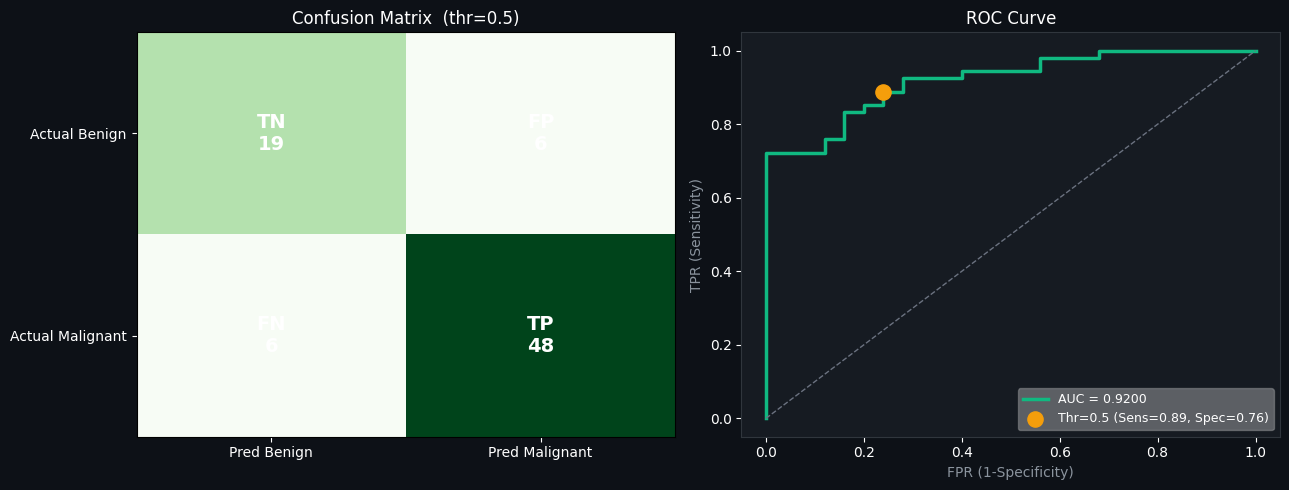

In [6]:
if not SKLEARN_OK:
    print("sklearn needed for this cell")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="#0d1117")

    # Confusion matrix
    ax = axes[0]; ax.set_facecolor("#161b22")
    cm_v = np.array([[tn3, fp3], [fn3, tp3]])
    im   = ax.imshow(cm_v, cmap="Greens", aspect="auto")
    for i in range(2):
        for j in range(2):
            lbl = [["TN","FP"],["FN","TP"]][i][j]
            ax.text(j, i, f"{lbl}\n{cm_v[i,j]}",
                    ha="center", va="center", color="white", fontsize=14, fontweight="bold")
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred Benign","Pred Malignant"], color="white")
    ax.set_yticks([0,1]); ax.set_yticklabels(["Actual Benign","Actual Malignant"], color="white")
    ax.set_title(f"Confusion Matrix  (thr={THRESHOLD3})", color="white", fontsize=12)
    ax.tick_params(colors="white")

    # ROC curve
    ax2 = axes[1]; ax2.set_facecolor("#161b22")
    fpr, tpr, _ = roc_curve(labels3_all, probs3_all)
    ax2.plot(fpr, tpr, color="#10b981", lw=2.5, label=f"AUC = {auc3:.4f}")
    ax2.plot([0,1],[0,1], color="#6b7280", lw=1, linestyle="--")
    ax2.scatter([1-spec3],[sens3], color="#f59e0b", s=120, zorder=5,
                label=f"Thr={THRESHOLD3} (Sens={sens3:.2f}, Spec={spec3:.2f})")
    ax2.set_xlabel("FPR (1-Specificity)", color="#8b949e")
    ax2.set_ylabel("TPR (Sensitivity)", color="#8b949e")
    ax2.set_title("ROC Curve", color="white", fontsize=12)
    ax2.tick_params(colors="white"); ax2.spines[:].set_color("#30363d")
    ax2.legend(fontsize=9, labelcolor="white", framealpha=0.3)

    plt.tight_layout()
    plt.savefig("stage3_roc_cm.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
    plt.show()

## 6. Threshold Sweep

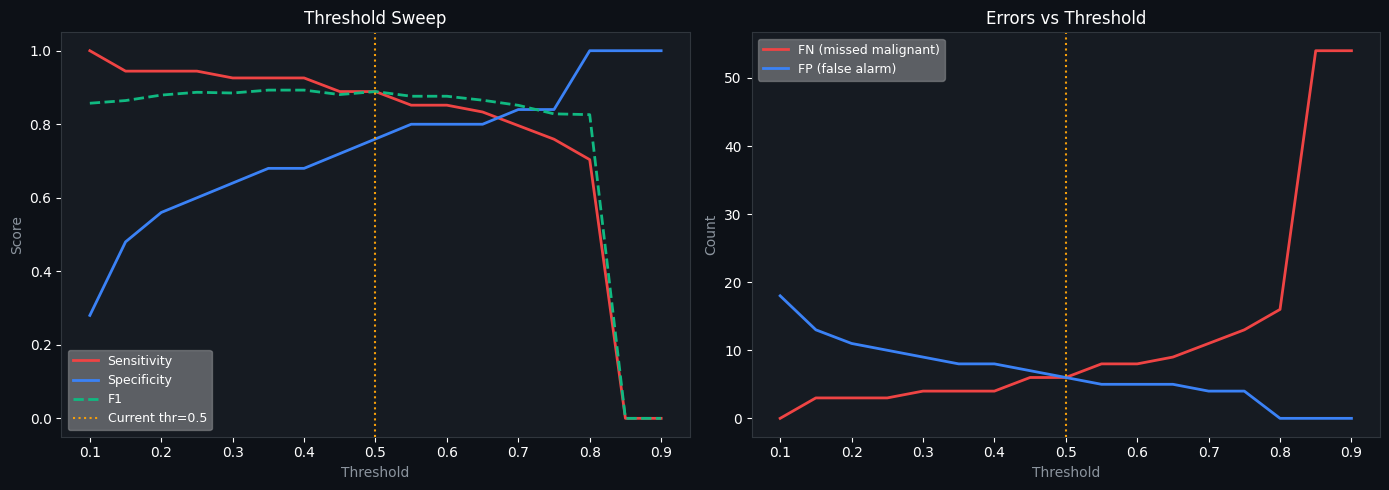

  Best F1 threshold : 0.35  (F1=0.8929, Sens=0.9259, Spec=0.6800, FN=4, FP=8)


In [7]:
if not SKLEARN_OK:
    print("sklearn needed")
else:
    thresholds3 = np.arange(0.1, 0.91, 0.05)
    res3 = []
    for t in thresholds3:
        pr      = (probs3_all >= t).astype(int)
        f1t     = float(f1_score(labels3_all, pr, zero_division=0))
        cm_t    = confusion_matrix(labels3_all, pr, labels=[0,1])
        tn_t,fp_t,fn_t,tp_t = cm_t.ravel()
        s_t     = float(tp_t/(tp_t+fn_t)) if (tp_t+fn_t) else 0
        sp_t    = float(tn_t/(tn_t+fp_t)) if (tn_t+fp_t) else 0
        acc_t   = float((pr == labels3_all).mean())
        res3.append({"t": t, "f1": f1t, "sens": s_t, "spec": sp_t, "acc": acc_t,
                     "fn": int(fn_t), "fp": int(fp_t)})

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0d1117")
    ts = [r["t"] for r in res3]

    ax = axes[0]; ax.set_facecolor("#161b22")
    ax.plot(ts, [r["sens"] for r in res3], color="#ef4444", lw=2, label="Sensitivity")
    ax.plot(ts, [r["spec"] for r in res3], color="#3b82f6", lw=2, label="Specificity")
    ax.plot(ts, [r["f1"]   for r in res3], color="#10b981", lw=2, linestyle="--", label="F1")
    ax.axvline(THRESHOLD3, color="#f59e0b", lw=1.5, linestyle=":", label=f"Current thr={THRESHOLD3}")
    ax.set_xlabel("Threshold", color="#8b949e"); ax.set_ylabel("Score", color="#8b949e")
    ax.set_title("Threshold Sweep", color="white", fontsize=12)
    ax.tick_params(colors="white"); ax.spines[:].set_color("#30363d")
    ax.legend(fontsize=9, labelcolor="white", framealpha=0.3)

    ax2 = axes[1]; ax2.set_facecolor("#161b22")
    ax2.plot(ts, [r["fn"] for r in res3], color="#ef4444", lw=2, label="FN (missed malignant)")
    ax2.plot(ts, [r["fp"] for r in res3], color="#3b82f6", lw=2, label="FP (false alarm)")
    ax2.axvline(THRESHOLD3, color="#f59e0b", lw=1.5, linestyle=":")
    ax2.set_xlabel("Threshold", color="#8b949e"); ax2.set_ylabel("Count", color="#8b949e")
    ax2.set_title("Errors vs Threshold", color="white", fontsize=12)
    ax2.tick_params(colors="white"); ax2.spines[:].set_color("#30363d")
    ax2.legend(fontsize=9, labelcolor="white", framealpha=0.3)

    plt.tight_layout()
    plt.savefig("stage3_threshold_sweep.png", dpi=130, bbox_inches="tight", facecolor="#0d1117")
    plt.show()

    best_f1_r = max(res3, key=lambda r: r["f1"])
    print(f"  Best F1 threshold : {best_f1_r['t']:.2f}  (F1={best_f1_r['f1']:.4f},"
          f" Sens={best_f1_r['sens']:.4f}, Spec={best_f1_r['spec']:.4f},"
          f" FN={best_f1_r['fn']}, FP={best_f1_r['fp']})")

## 7. Per-Patient Probability Plot

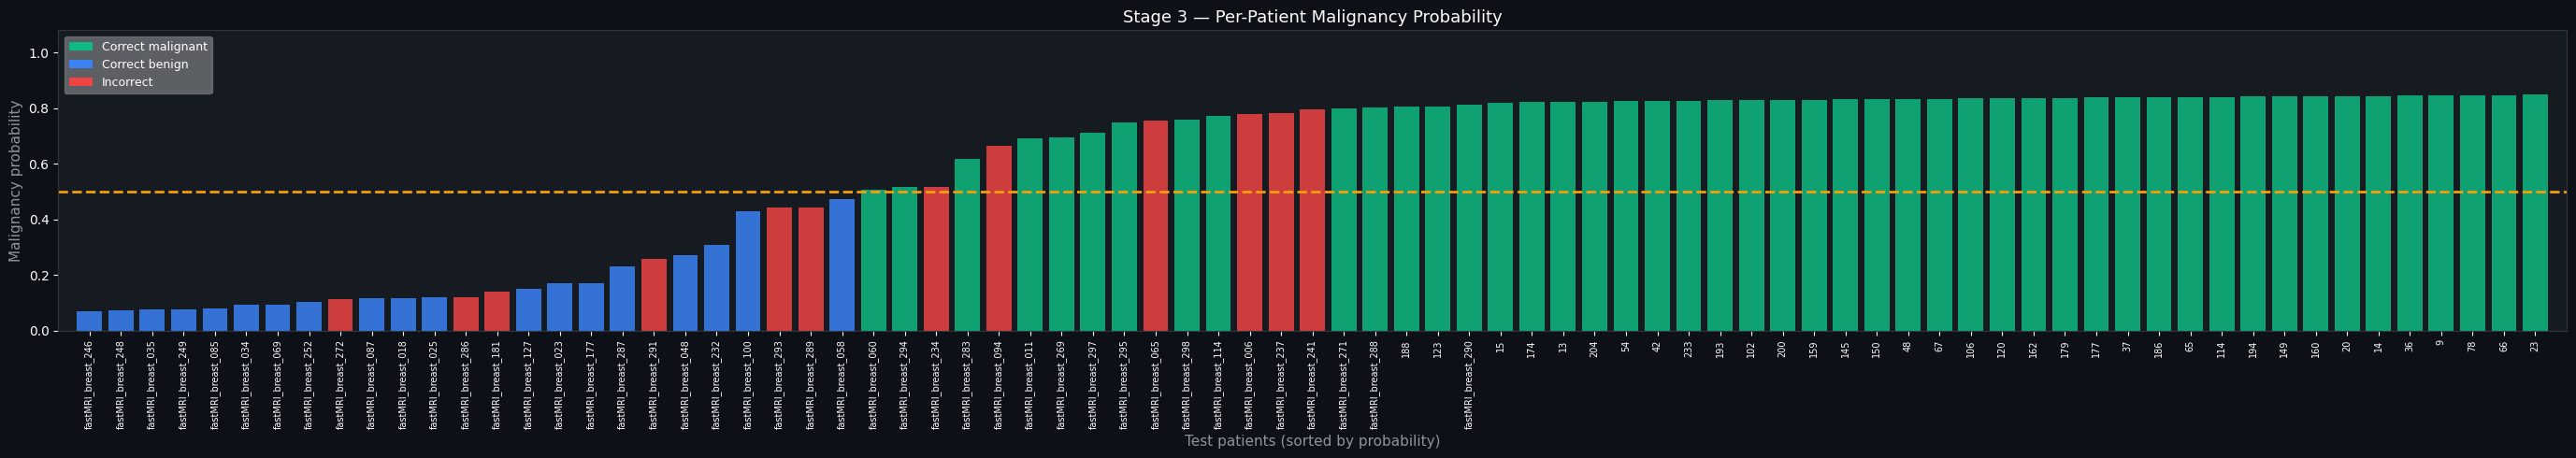

  Green=correct malignant  Blue=correct benign  Red=incorrect


In [8]:
sorted_idx3 = np.argsort(probs3_all)
s_probs  = probs3_all[sorted_idx3]
s_labels = labels3_all[sorted_idx3]
s_pids   = [pids3_all[i] for i in sorted_idx3]

bar_col3 = []
for prob, label in zip(s_probs, s_labels):
    pred = int(prob >= THRESHOLD3)
    if pred == label:
        bar_col3.append("#10b981" if label == 1 else "#3b82f6")
    else:
        bar_col3.append("#ef4444")

fig, ax = plt.subplots(figsize=(max(14, len(s_probs)*0.35), 5), facecolor="#0d1117")
ax.set_facecolor("#161b22")
bars = ax.bar(range(len(s_probs)), s_probs, color=bar_col3, width=0.8, alpha=0.85)
ax.axhline(THRESHOLD3, color="#f59e0b", lw=2, linestyle="--", label=f"Threshold={THRESHOLD3}")
ax.set_xticks(range(len(s_pids)))
ax.set_xticklabels(s_pids, rotation=90, fontsize=7, color="#8b949e")
ax.set_ylabel("Malignancy probability", color="#8b949e", fontsize=11)
ax.set_xlabel("Test patients (sorted by probability)", color="#8b949e", fontsize=11)
ax.set_title("Stage 3 — Per-Patient Malignancy Probability", color="white", fontsize=13)
ax.tick_params(colors="white"); ax.spines[:].set_color("#30363d")
ax.set_ylim(0, 1.08); ax.set_xlim(-1, len(s_probs))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#10b981", label="Correct malignant"),
    Patch(facecolor="#3b82f6", label="Correct benign"),
    Patch(facecolor="#ef4444", label="Incorrect"),
]
ax.legend(handles=legend_elements, fontsize=9, labelcolor="white",
          framealpha=0.3, loc="upper left")

plt.tight_layout()
plt.savefig("stage3_patient_probs.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"  Green=correct malignant  Blue=correct benign  Red=incorrect")

## 8. Patient Visualiser (64³ Crop + DCE Kinetics)

In [12]:
def _get_centroid_3d(label_npy):
    if label_npy is None or label_npy.sum() == 0:
        return None
    coords = np.argwhere(label_npy > 0.5)
    return coords.mean(axis=0).astype(int)

def show_stage3_patient(patient_dir, true_label=None, prob=None,
                         n_slices=5, figsize=(18, 9)):
    import numpy as np 
    pid      = os.path.basename(patient_dir)
    img_path = os.path.join(patient_dir, "image.npy")
    lbl_path = os.path.join(patient_dir, "label.npy")

    if not os.path.isfile(img_path):
        print(f"  [SKIP] {pid} — image.npy not found")
        return None

    img = np.load(img_path).astype(np.float32)
    lbl = np.load(lbl_path).astype(np.float32) if os.path.isfile(lbl_path) else None

    if prob is None:
        # Must crop 64³ patch before inference — model expects CROP_SIZE³, not full volume
        from data_stage3 import _crop_patch
        import numpy as np
        patch = _crop_patch(img, lbl, CROP_SIZE)          # (3, 64, 64, 64)
        patch = np.clip(patch, -3.5, 7.0)
        t     = torch.from_numpy(patch).unsqueeze(0).to(device)  # (1, 3, 64, 64, 64)
        model.eval()
        with torch.no_grad():
            with autocast(device_type=device.type, enabled=(device.type=="cuda")):
                logit = model(t)
        prob = float(torch.sigmoid(logit).cpu().item())

    pred_lbl = int(prob >= THRESHOLD3)
    pred_str = "MALIGNANT" if pred_lbl else "BENIGN"

    D, H, W   = img.shape[1], img.shape[2], img.shape[3]
    centroid  = _get_centroid_3d(lbl[0] if lbl is not None else None)
    if centroid is None:
        centroid = np.array([D//2, H//2, W//2])
    cz, cy, cx = centroid

    fig = plt.figure(figsize=figsize, facecolor="#0d1117")
    gs  = gridspec.GridSpec(4, n_slices, figure=fig, hspace=0.08, wspace=0.04)

    D_range  = np.linspace(max(0, cz-n_slices*3), min(D-1, cz+n_slices*3), n_slices, dtype=int)
    cmaps    = ["gray", "inferno", "viridis"]
    ch_names = ["P1", "P2", "P3"]

    for ch in range(3):
        for si, sl_idx in enumerate(D_range):
            ax = fig.add_subplot(gs[ch, si])
            ax.set_facecolor("#000")
            slc = img[ch, sl_idx]
            nz  = slc[slc > 0]
            p1, p99 = (np.percentile(nz, [2, 98]) if len(nz) > 0 else (0, 1))
            ax.imshow(slc, cmap=cmaps[ch], vmin=p1, vmax=p99, aspect="auto")
            ax.scatter([cx], [cy], marker="+", s=60, c="lime", linewidths=1.5, zorder=5)
            ax.axis("off")
            if si == 0:  ax.set_ylabel(ch_names[ch], color="white", fontsize=9)
            if ch == 0:  ax.set_title(f"z={sl_idx}", color="#8b949e", fontsize=7)

    ax_kin = fig.add_subplot(gs[3, :])
    ax_kin.set_facecolor("#161b22")
    if lbl is not None and lbl.sum() > 0:
        mask  = (lbl[0] > 0.5)
        means = [img[ch][mask].mean() for ch in range(3)]
    else:
        means = [img[ch].mean() for ch in range(3)]

    ax_kin.plot([1,2,3], means, "o-", color="#3b82f6", lw=2.5, ms=8)
    ax_kin.fill_between([1,2,3], means, alpha=0.15, color="#3b82f6")
    k_type = ("Washout (Type III)" if means[2] < means[1]*0.9
              else "Plateau (Type II)" if means[2] < means[1]*1.1
              else "Persistent (Type I)")
    ax_kin.set_title(f"DCE Kinetics: {k_type}", color="white", fontsize=10)
    ax_kin.set_xticks([1,2,3]); ax_kin.set_xticklabels(["P1","P2","P3"], color="white")
    ax_kin.tick_params(colors="white"); ax_kin.spines[:].set_color("#30363d")
    ax_kin.set_ylabel("Mean intensity", color="#8b949e", fontsize=8)

    status = ""
    if true_label is not None:
        status = "  ✓ CORRECT" if pred_lbl == true_label else "  ✗ WRONG"
    true_str = f"  True: {'MAL' if true_label==1 else 'BEN'}" if true_label is not None else ""
    fig.suptitle(f"{pid}  Prob={prob:.4f}  Pred: {pred_str}{true_str}{status}",
                 color="white", fontsize=12, y=1.0)
    plt.savefig(f"stage3_slices_{pid}.png", dpi=110, bbox_inches="tight", facecolor="#0d1117")
    plt.show()
    return prob

print("  Stage 3 visualiser ready.")
print("  Usage: show_stage3_patient(patient_dir, true_label=1)")

  Stage 3 visualiser ready.
  Usage: show_stage3_patient(patient_dir, true_label=1)


## 9. Specific Patient Investigation

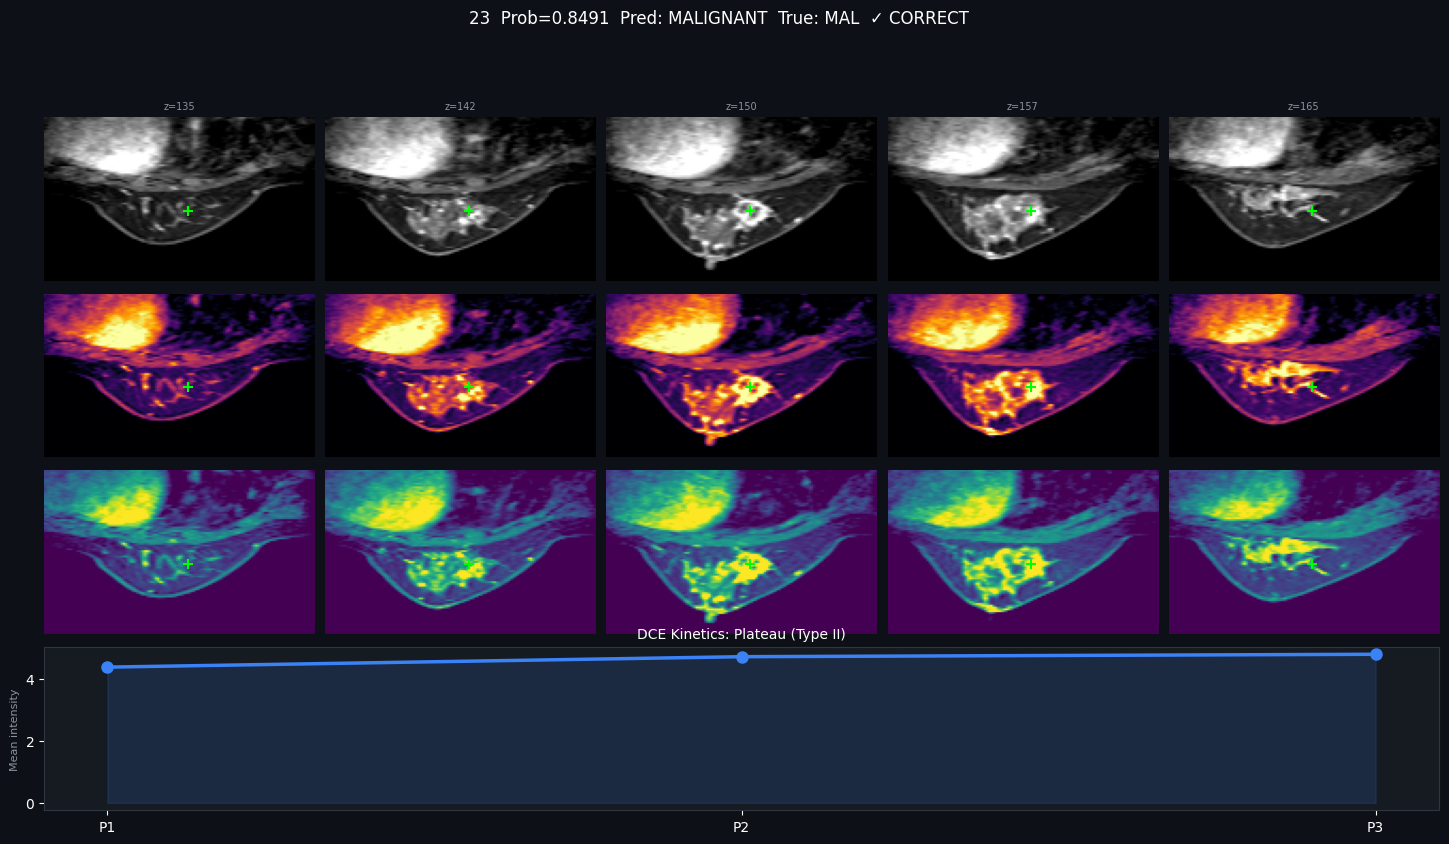

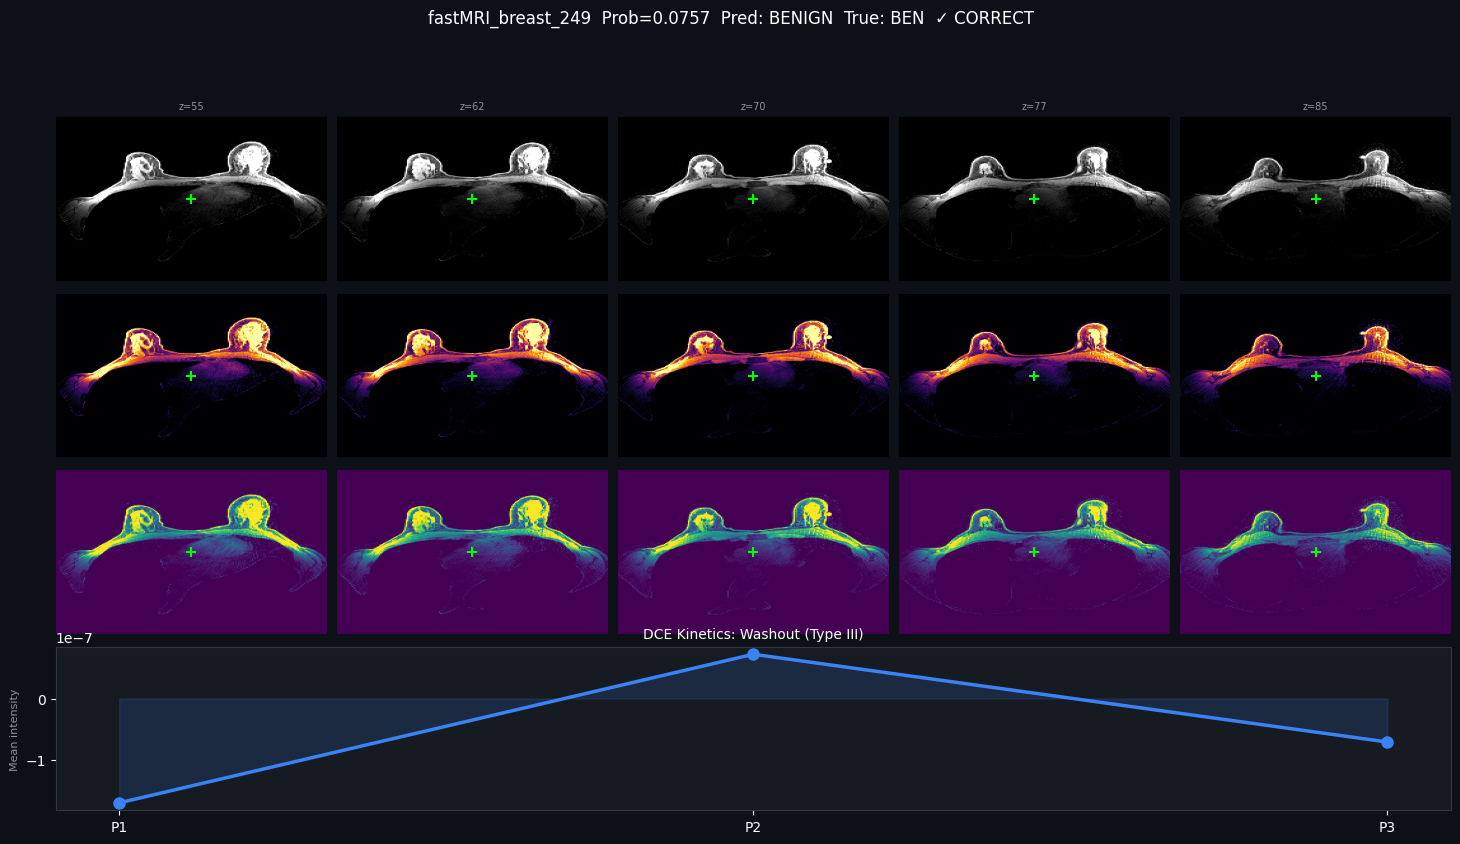

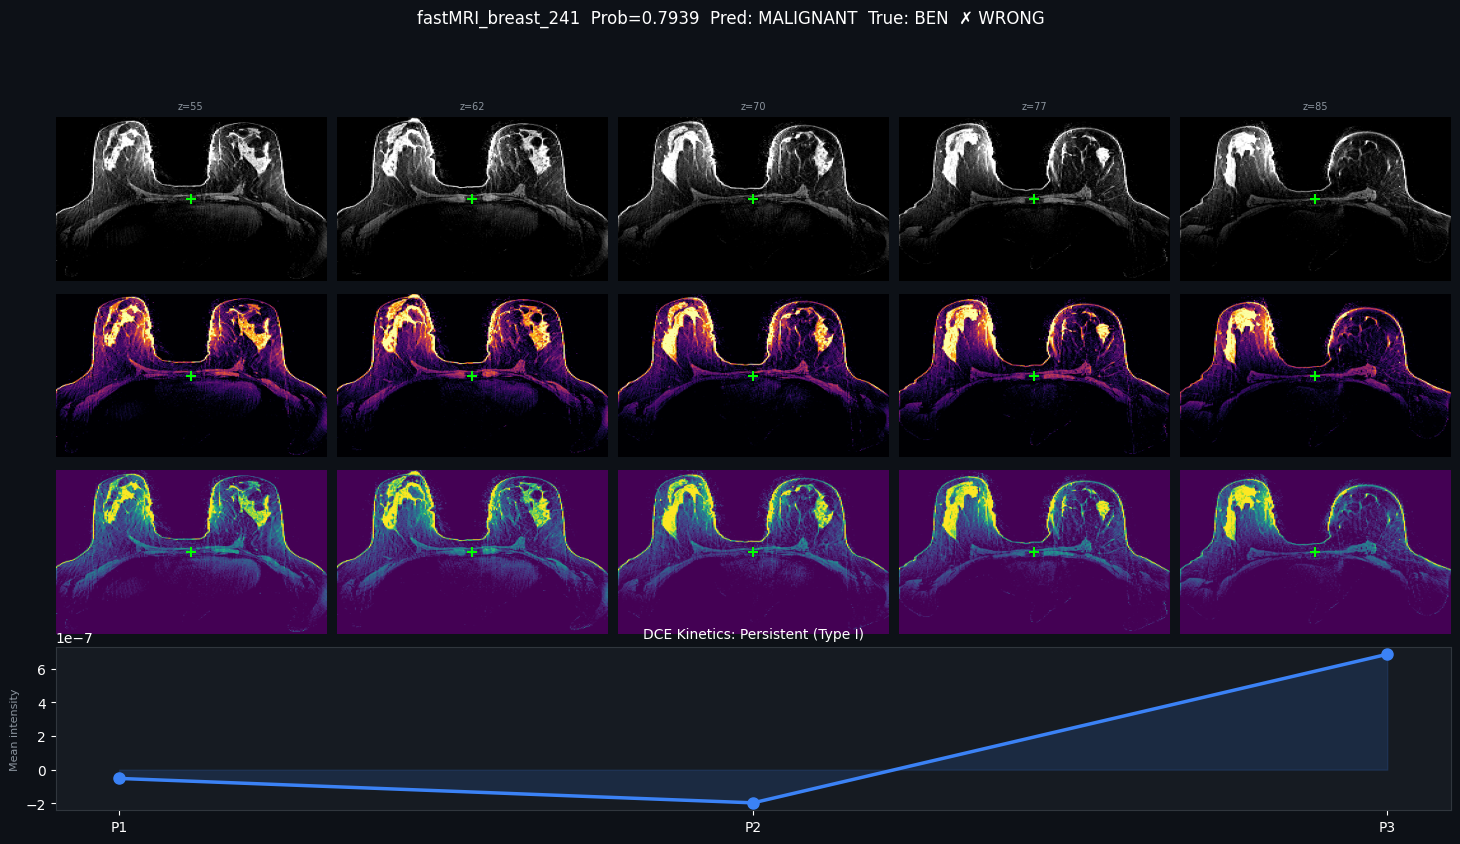

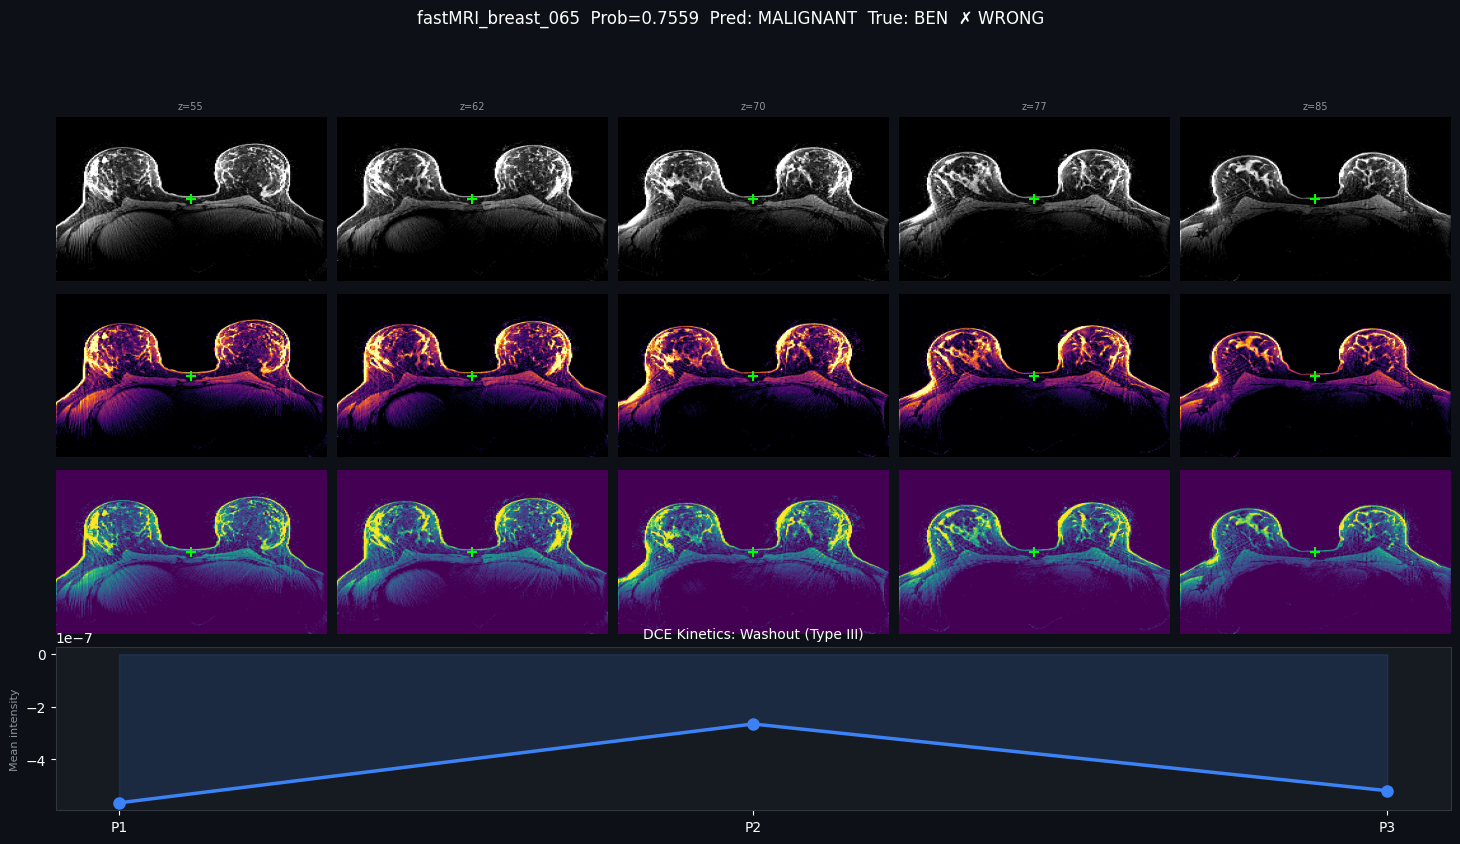

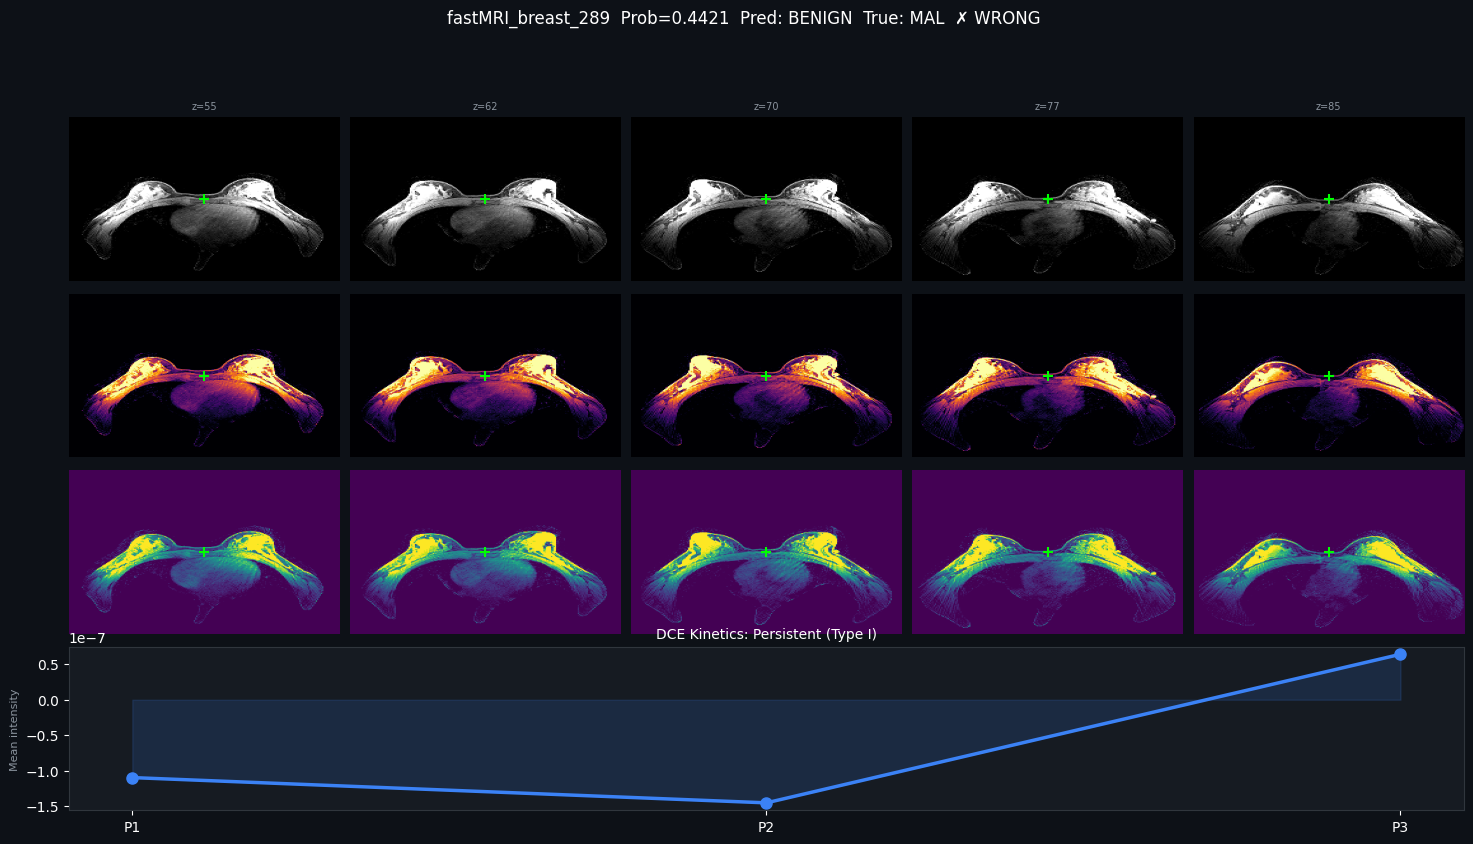

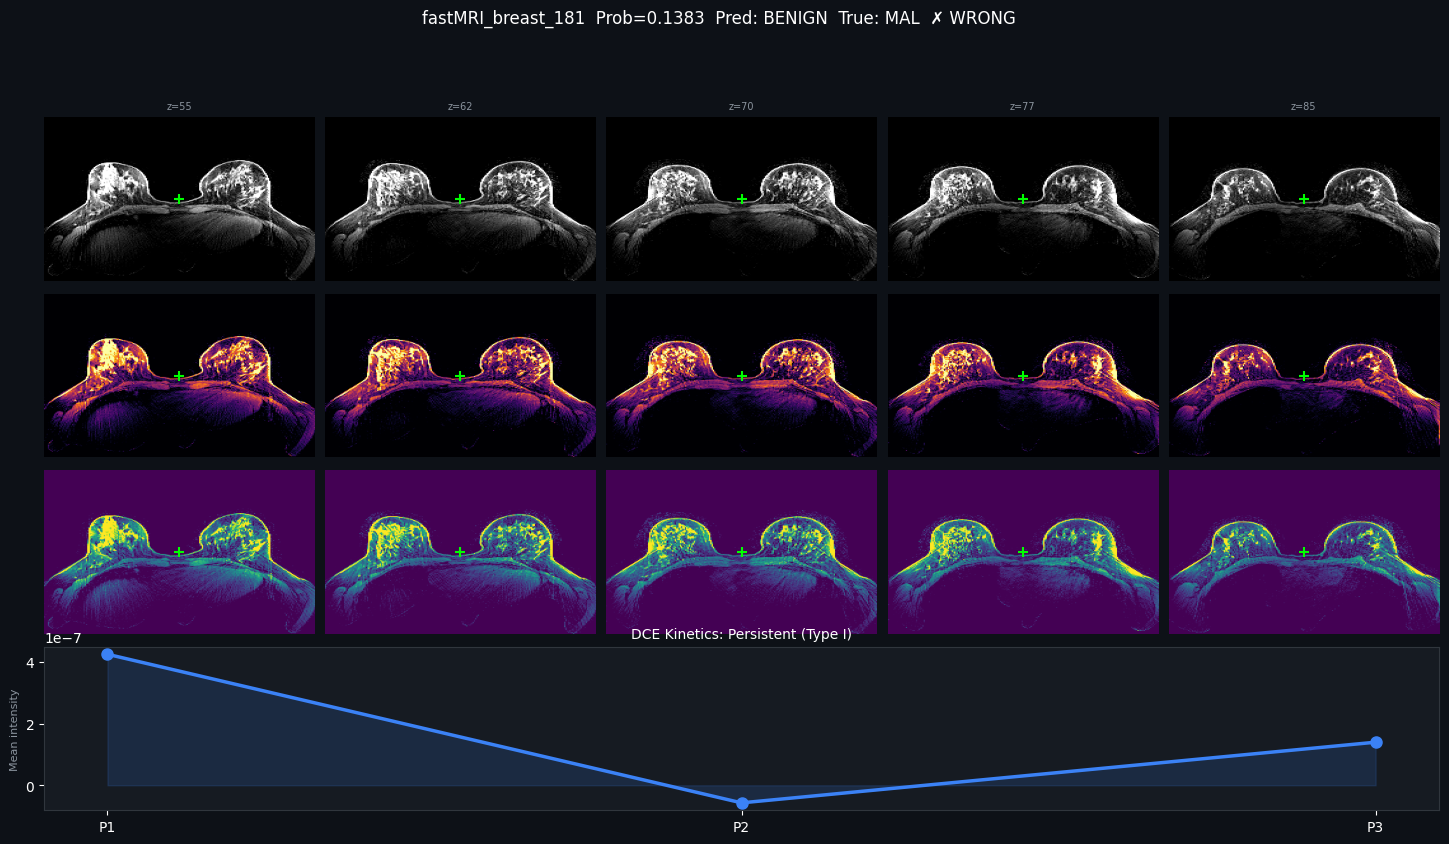

In [13]:
# ─── Edit patient IDs here ─────────────────────────────────────
SPECIFIC_PATIENTS_3 = [
    # (patient_id,              split,  class_folder, true_label)
    # ── HIGH-CONFIDENCE CORRECT ─────────────────────────────────
    ("23",                      "test", "malignant",  1),   # prob=0.849 ✓ MAL
    ("fastMRI_breast_249",      "test", "benign",     0),   # prob=0.076 ✓ BEN
    # ── FALSE POSITIVES (benign → predicted malignant) ──────────
    ("fastMRI_breast_241",      "test", "benign",     0),   # prob=0.794 ✗ FP
    ("fastMRI_breast_065",      "test", "benign",     0),   # prob=0.755 ✗ FP
    # ── FALSE NEGATIVES (malignant → predicted benign) ──────────
    ("fastMRI_breast_289",      "test", "malignant",  1),   # prob=0.443 ✗ FN
    ("fastMRI_breast_181",      "test", "malignant",  1),   # prob=0.138 ✗ FN
]

for pid, split, cls_folder, true_lbl in SPECIFIC_PATIENTS_3:
    patient_dir = os.path.join(DATA_ROOT, split, cls_folder, pid)
    if not os.path.isdir(patient_dir):
        print(f"  [SKIP] {pid} — not found at {patient_dir}")
        continue
    show_stage3_patient(patient_dir, true_label=true_lbl, n_slices=5)
    print()

## 10. Random Patient Gallery

Showing 6 random patients:



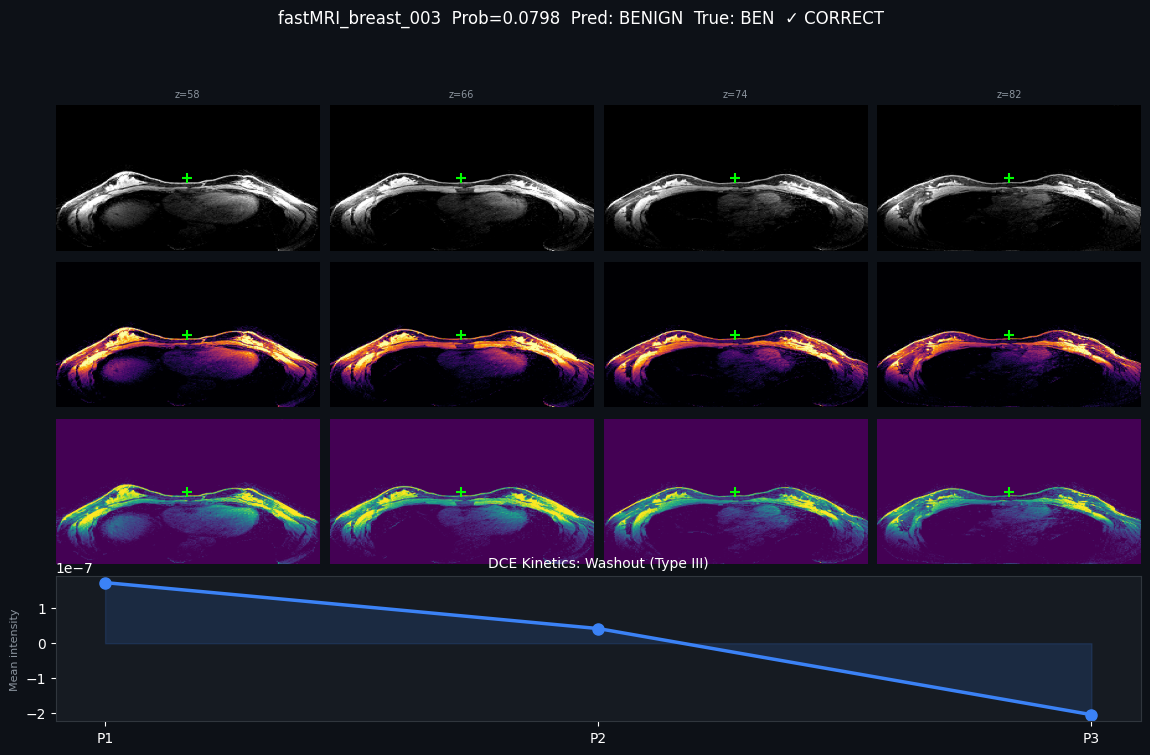

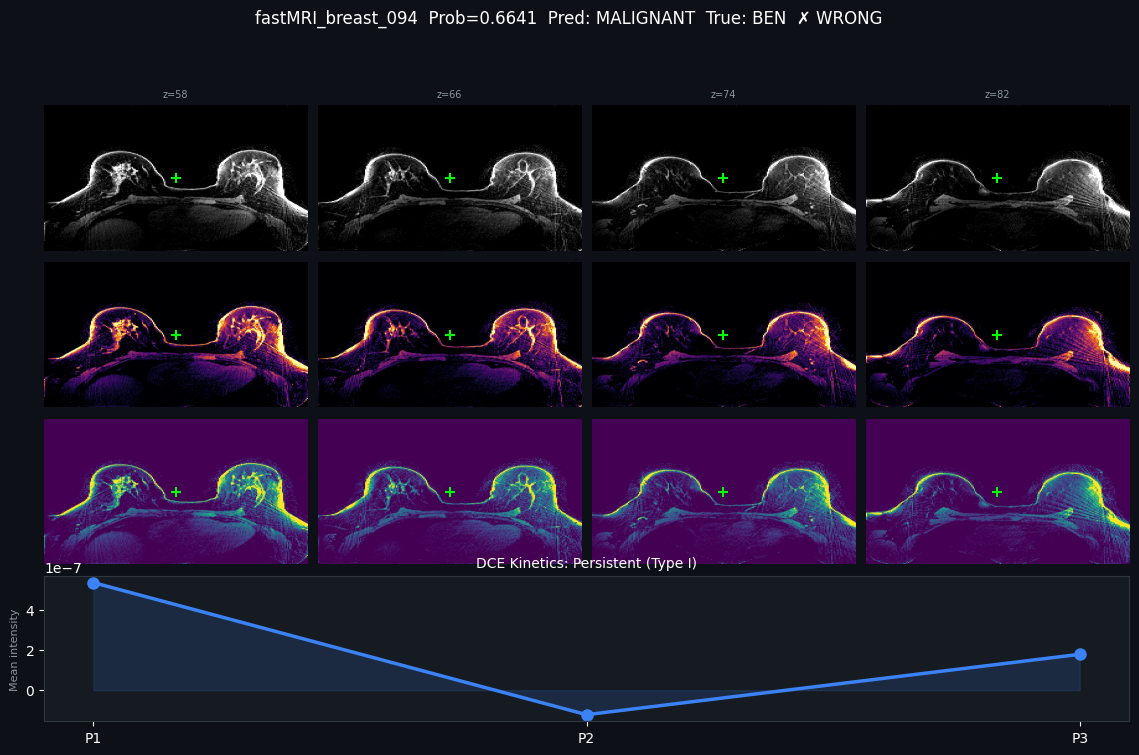

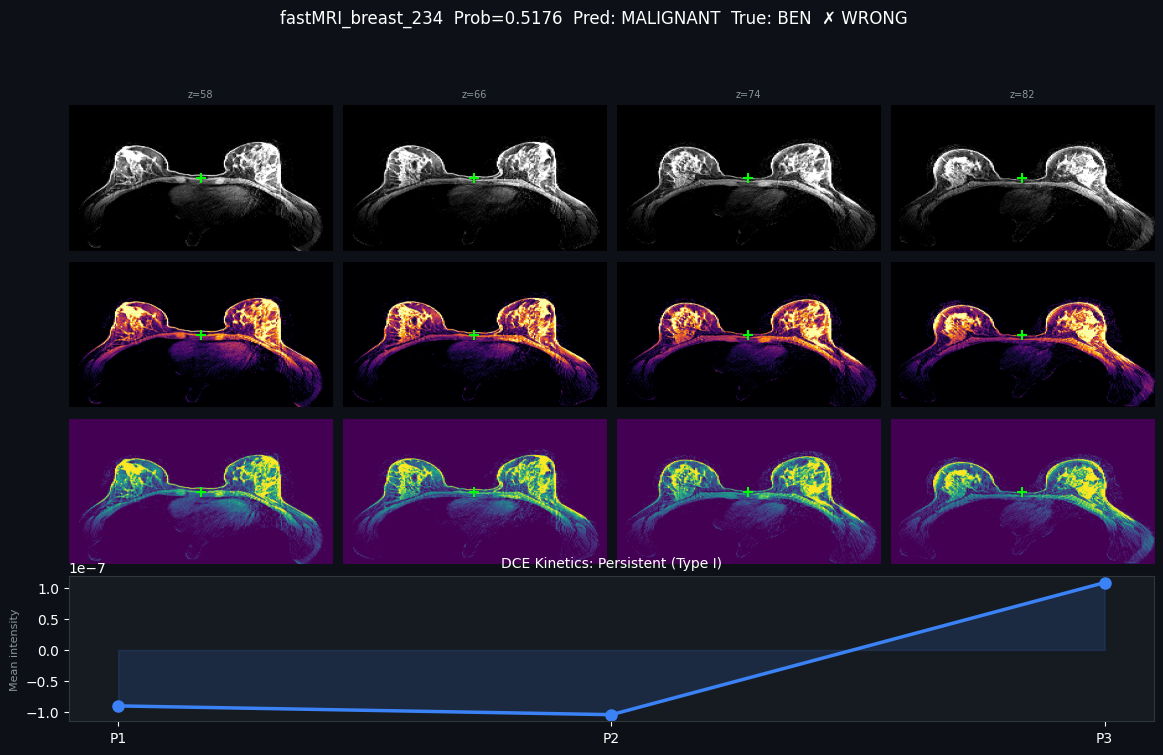

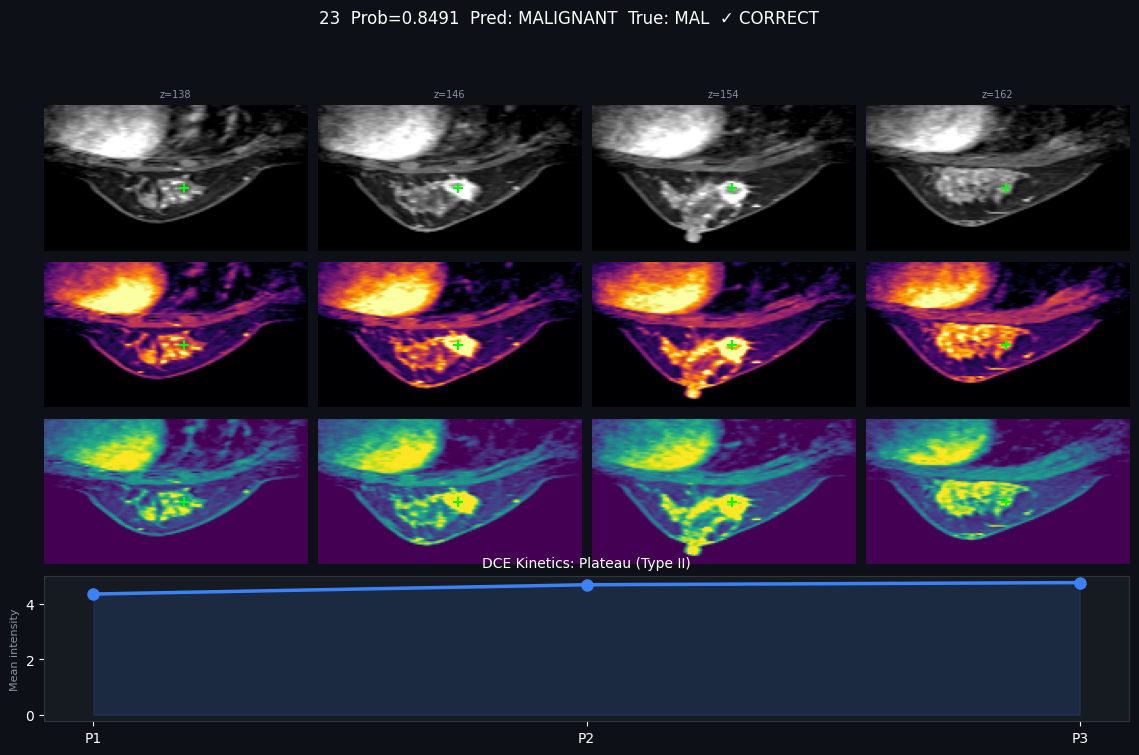

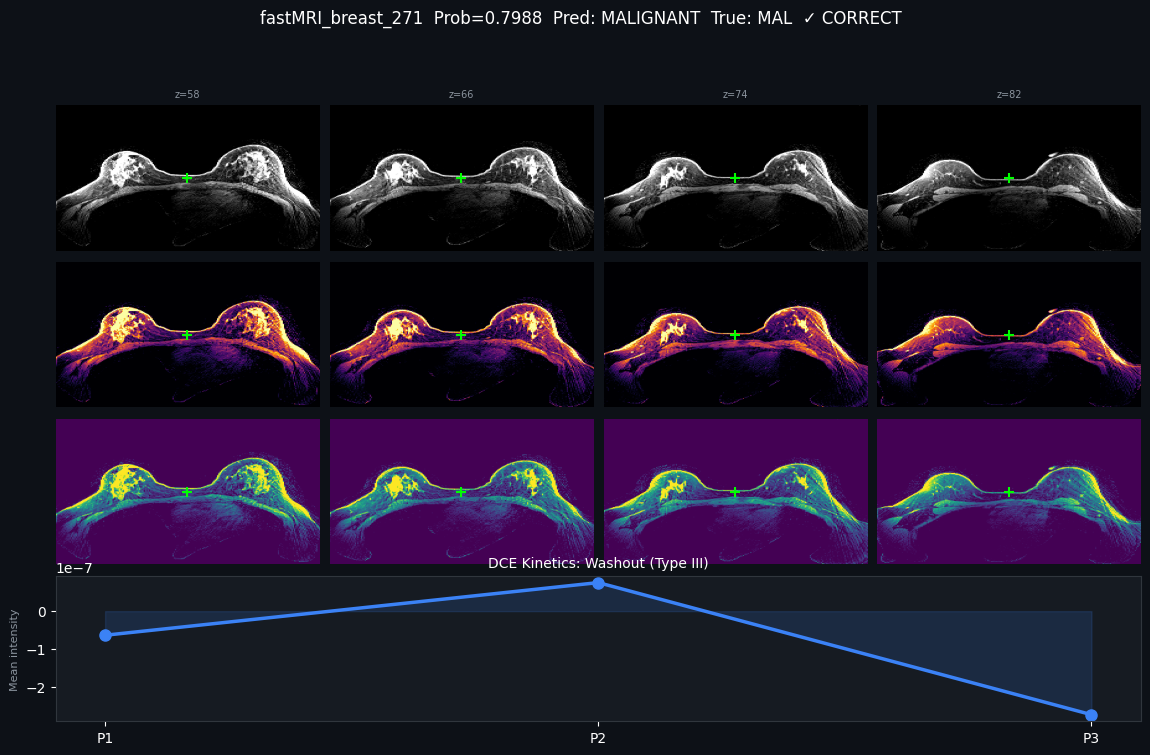

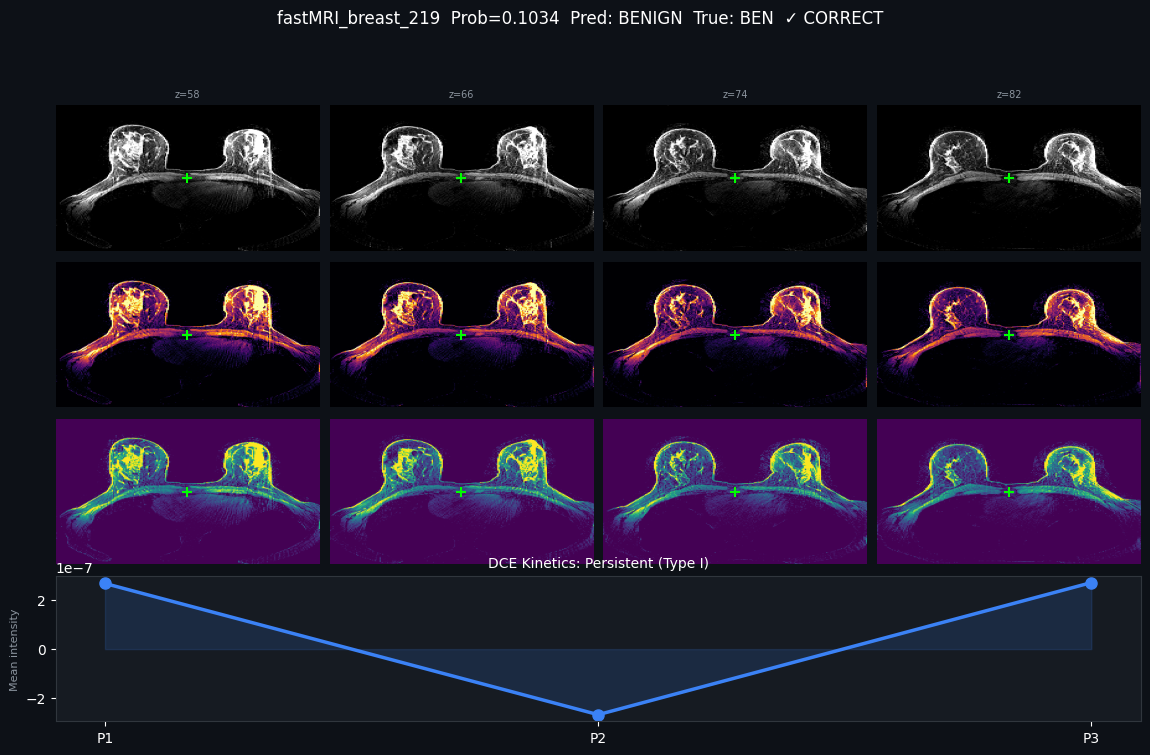

In [14]:
N_RANDOM_3 = 6
random.seed(99)
pool3 = []
for cls, lbl in [("malignant", 1), ("benign", 0)]:
    for split in ("test", "val"):
        cls_dir = os.path.join(DATA_ROOT, split, cls)
        if os.path.isdir(cls_dir):
            for pid in os.listdir(cls_dir):
                if os.path.isfile(os.path.join(cls_dir, pid, "image.npy")):
                    pool3.append((pid, split, cls, lbl))

random.shuffle(pool3)
pool3 = pool3[:N_RANDOM_3]
print(f"Showing {len(pool3)} random patients:\n")
for pid, split, cls, true_lbl in pool3:
    show_stage3_patient(os.path.join(DATA_ROOT, split, cls, pid),
                        true_label=true_lbl, n_slices=4, figsize=(14, 8))
    print()

## 11. Summary Card

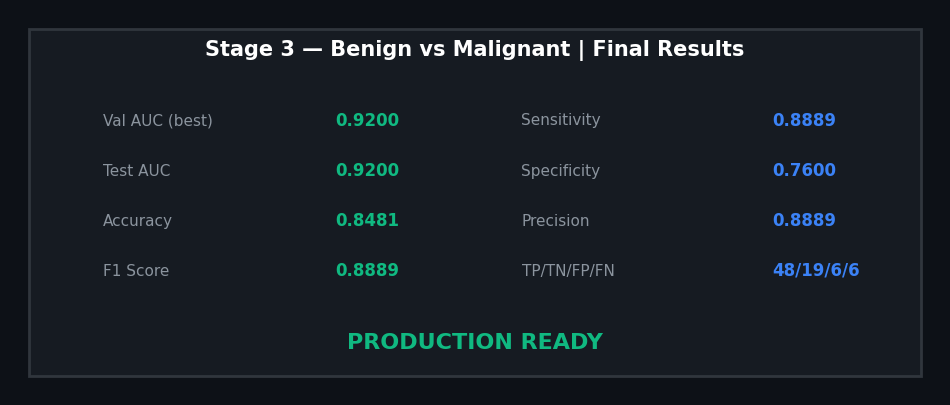

  Stage 3 notebook complete.


In [15]:
fig, ax = plt.subplots(figsize=(12, 5), facecolor="#0d1117")
ax.set_facecolor("#0d1117"); ax.axis("off")

card = plt.Rectangle((0.02, 0.05), 0.96, 0.9, transform=ax.transAxes,
                      facecolor="#161b22", edgecolor="#30363d",
                      linewidth=2, zorder=1, clip_on=False)
ax.add_patch(card)

ax.text(0.5, 0.88, "Stage 3 — Benign vs Malignant | Final Results",
        transform=ax.transAxes, ha="center", color="white",
        fontsize=15, fontweight="bold")

best_hist_auc = max(hist3["val_auc"]) if hist3["val_auc"] else 0.0
metrics_l = [
    ("Val AUC (best)",  f"{best_hist_auc:.4f}"),
    ("Test AUC",        f"{auc3:.4f}"),
    ("Accuracy",        f"{acc3:.4f}"),
    ("F1 Score",        f"{f1_3:.4f}"),
]
metrics_r = [
    ("Sensitivity",  f"{sens3:.4f}"),
    ("Specificity",  f"{spec3:.4f}"),
    ("Precision",    f"{ppv3:.4f}"),
    ("TP/TN/FP/FN", f"{tp3}/{tn3}/{fp3}/{fn3}"),
]
for i, (k, v) in enumerate(metrics_l):
    y = 0.70 - i*0.13
    ax.text(0.10, y, k, transform=ax.transAxes, color="#8b949e", fontsize=11)
    ax.text(0.35, y, v, transform=ax.transAxes, color="#10b981", fontsize=12, fontweight="bold")

for i, (k, v) in enumerate(metrics_r):
    y = 0.70 - i*0.13
    ax.text(0.55, y, k, transform=ax.transAxes, color="#8b949e", fontsize=11)
    ax.text(0.82, y, v, transform=ax.transAxes, color="#3b82f6", fontsize=12, fontweight="bold")

status_t = "PRODUCTION READY" if auc3 >= 0.85 else "GOOD — RETRAIN AVAILABLE"
status_c = "#10b981" if auc3 >= 0.85 else "#f59e0b"
ax.text(0.5, 0.12, status_t, transform=ax.transAxes, ha="center",
        color=status_c, fontsize=16, fontweight="bold")

plt.savefig("stage3_summary_card.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("  Stage 3 notebook complete.")